
# MNIST Digit Classification using CNN - Student Workbook

## Learning Outcomes
After completing this notebook, students will be able to:

1. Understand the MNIST dataset.
2. Perform basic EDA.
3. Preprocess image data for CNN.
4. Build a CNN using TensorFlow/Keras.
5. Train and evaluate a model.
6. Interpret Confusion Matrix and Classification Report.
7. Predict a new handwritten digit image.

---

## What is CNN?

CNN (Convolutional Neural Network) is a Deep Learning model designed for image processing.

CNN automatically learns:
- Edges
- Curves
- Shapes
- Patterns

which makes it suitable for image classification tasks.



# MNIST Digit Classification Using CNN

## Workflow Covered

1. Load Train and Test CSV Files
2. Exploratory Data Analysis (EDA)
3. Dataset Description and Class Percentages
4. Data Preprocessing
5. CNN with 3 Convolution Layers
6. ReLU Activation
7. Dropout
8. Softmax Output Layer
9. Early Stopping
10. Accuracy and Loss Graphs
11. Overfitting Analysis
12. Confusion Matrix
13. Classification Report
14. Sample Predictions
15. Upload New Handwritten Digit Image
16. Predict User Uploaded Image



# Understanding the Libraries

### NumPy
Used for numerical operations and arrays.

### Pandas
Used to load and manipulate CSV datasets.

### Matplotlib
Used to display images and graphs.

### Seaborn
Used for advanced visualizations.

### TensorFlow / Keras
Framework used to build and train Deep Learning models.

### PIL
Used for reading and preprocessing uploaded images.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical


## Mount Google Drive

In [16]:

from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Load Train and Test CSV Files

In [18]:

train_df = pd.read_csv('/content/drive/MyDrive/mnist_train.csv')
test_df = pd.read_csv('/content/drive/MyDrive/mnist_test.csv')

print("Train Shape :", train_df.shape)
print("Test Shape  :", test_df.shape)

train_df.head()


Train Shape : (60000, 785)
Test Shape  : (10000, 785)


,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Dataset Description

In [19]:

print("Rows :", train_df.shape[0])
print("Columns :", train_df.shape[1])

print("Missing Values :", train_df.isnull().sum().sum())


Rows : 60000
Columns : 785
Missing Values : 0


## Class Distribution

In [20]:

class_count = train_df['label'].value_counts().sort_index()

class_percentage = (class_count/len(train_df))*100

print(class_count)

print("\nClass Percentage")
print(class_percentage.round(2))


label
0    5923
1    6742
2    5958
3    6131
4    5842
5    5421
6    5918
7    6265
8    5851
9    5949
Name: count, dtype: int64

Class Percentage
label
0     9.87
1    11.24
2     9.93
3    10.22
4     9.74
5     9.04
6     9.86
7    10.44
8     9.75
9     9.92
Name: count, dtype: float64


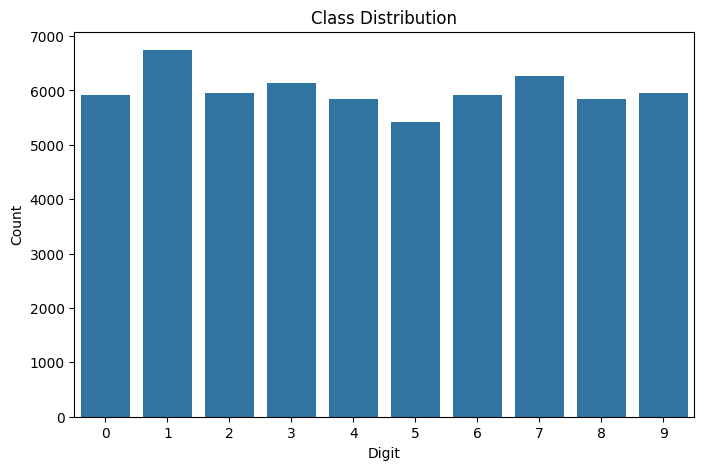

In [21]:

plt.figure(figsize=(8,5))

sns.barplot(
    x=class_count.index,
    y=class_count.values
)

plt.title("Class Distribution")
plt.xlabel("Digit")
plt.ylabel("Count")

plt.show()


## Display Sample Images

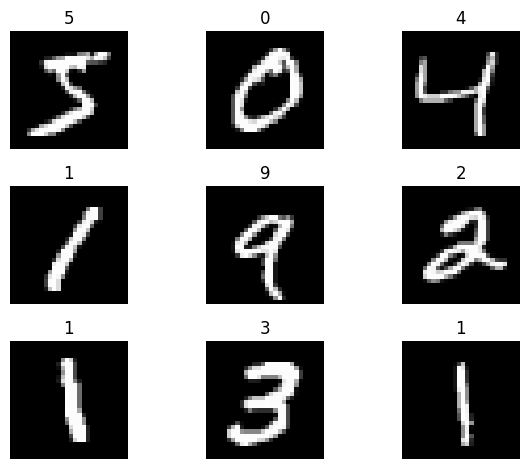

In [22]:

for i in range(9):

    plt.subplot(3,3,i+1)

    image = train_df.iloc[i,1:].values.reshape(28,28)

    plt.imshow(image,cmap='gray')

    plt.title(train_df.iloc[i,0])

    plt.axis('off')

plt.tight_layout()
plt.show()


## Data Preprocessing

In [23]:

X_train = train_df.iloc[:,1:].values
y_train = train_df.iloc[:,0].values

X_test = test_df.iloc[:,1:].values
y_test = test_df.iloc[:,0].values


In [24]:

X_train = X_train/255.0
X_test = X_test/255.0

X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

y_train = to_categorical(y_train,10)
y_test = to_categorical(y_test,10)

print(X_train.shape)
print(X_test.shape)


(60000, 28, 28, 1)
(10000, 28, 28, 1)


## CNN Model

In [25]:

model = Sequential()

model.add(
    Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation='relu',
        input_shape=(28,28,1)
    )
)

model.add(MaxPooling2D((2,2)))

model.add(
    Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation='relu'
    )
)

model.add(MaxPooling2D((2,2)))

model.add(
    Conv2D(
        filters=128,
        kernel_size=(3,3),
        activation='relu'
    )
)

model.add(Flatten())

model.add(Dense(128,activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(10,activation='softmax'))

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 241,546 (943.54 KB)

 Trainable params: 241,546 (943.54 KB)

 Non-trainable params: 0 (0.00 B)

## Compile Model

In [26]:

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


## Early Stopping

In [27]:

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)


## Train CNN

In [28]:

history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=128,
    validation_split=0.20,
    callbacks=[early_stop]
)


Epoch 1/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.8966 - loss: 0.3306 - val_accuracy: 0.9822 - val_loss: 0.0631
Epoch 2/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9745 - loss: 0.0865 - val_accuracy: 0.9818 - val_loss: 0.0576
Epoch 3/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9827 - loss: 0.0589 - val_accuracy: 0.9885 - val_loss: 0.0410
Epoch 4/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9857 - loss: 0.0468 - val_accuracy: 0.9892 - val_loss: 0.0390
Epoch 5/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9884 - loss: 0.0396 - val_accuracy: 0.9894 - val_loss: 0.0386
Epoch 6/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9911 - loss: 0.0300 - val_accuracy: 0.9892 - val_loss: 0.0430
Epoch 7/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9914 - loss: 0.0284 - val_accuracy: 0.9906 - val_loss: 0.0338
Epoch 8/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9931 - loss: 0.0235 - val_accuracy: 

## Accuracy and Loss Graphs

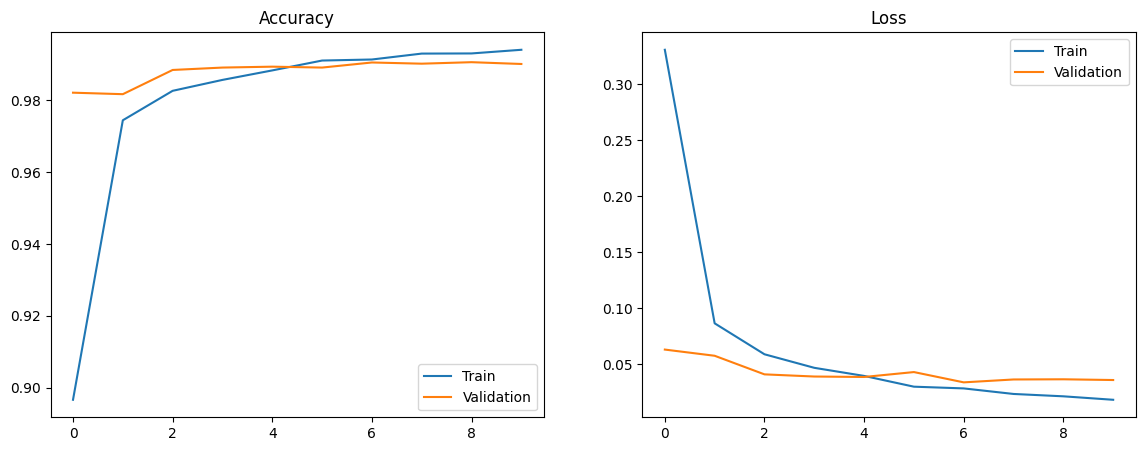

In [29]:

plt.figure(figsize=(14,5))

plt.subplot(1,2,1)

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Accuracy")
plt.legend(['Train','Validation'])

plt.subplot(1,2,2)

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Loss")
plt.legend(['Train','Validation'])

plt.show()


## Evaluate Model

In [30]:

loss,accuracy = model.evaluate(X_test,y_test)

print("Test Loss :",loss)
print("Test Accuracy :",accuracy)


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9927 - loss: 0.0247
Test Loss : 0.024664999917149544
Test Accuracy : 0.9926999807357788


## Predictions

In [31]:

y_pred_prob = model.predict(X_test)

y_pred = np.argmax(y_pred_prob,axis=1)

y_actual = np.argmax(y_test,axis=1)


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step


## Classification Report

In [32]:

print(classification_report(
    y_actual,
    y_pred
))


              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      1.00      0.99       982
           5       0.99      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       1.00      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



## Confusion Matrix

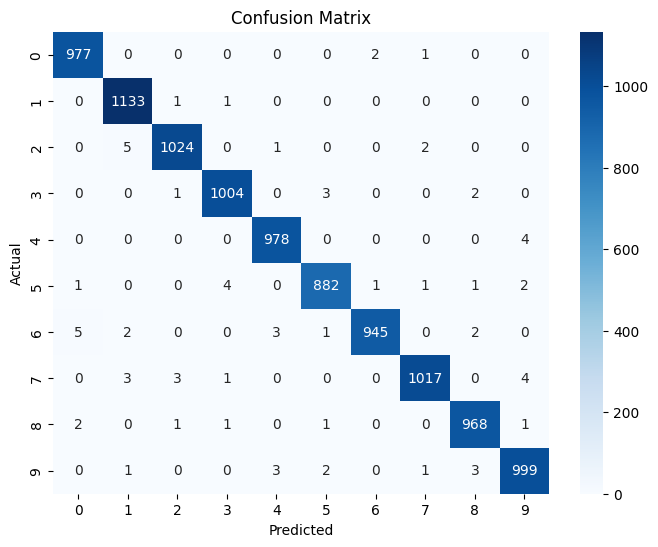

In [33]:

cm = confusion_matrix(
    y_actual,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()


## Show Test Predictions

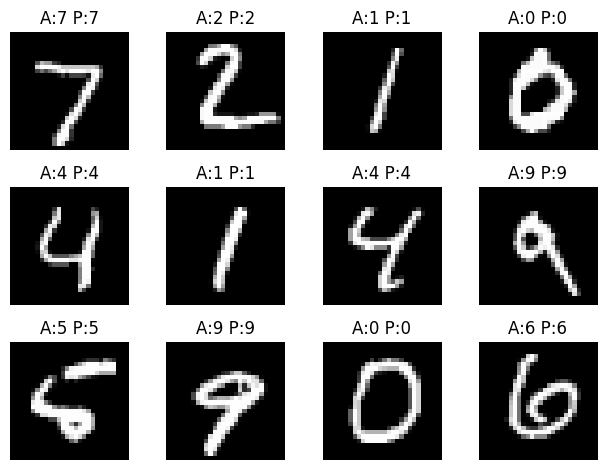

In [58]:
for i in range(12):

    plt.subplot(3,4,i+1)

    plt.imshow(
        X_test[i].reshape(28,28),
        cmap='gray'
    )

    plt.title(
        f"A:{y_actual[i]} P:{y_pred[i]}"
    )

    plt.axis('off')

plt.tight_layout()
plt.show()

## Upload New Handwritten Digit

In [59]:

from google.colab import files

uploaded = files.upload()

Saving 5.jpeg to 5 (1).jpeg


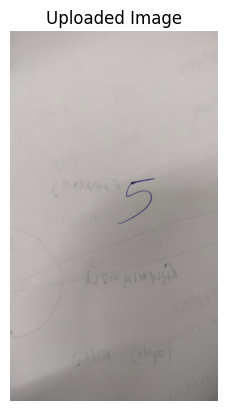

In [60]:
from PIL import Image

filename = list(uploaded.keys())[0]

img = Image.open(filename)

plt.imshow(img)

plt.title("Uploaded Image")

plt.axis('off')

plt.show()

## Preprocess Uploaded Image

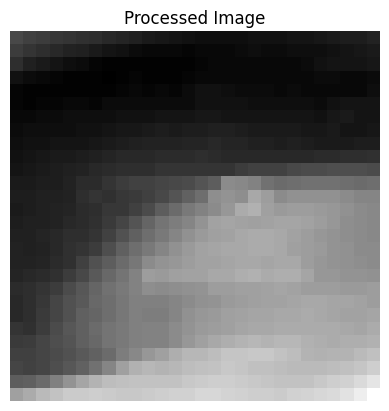

In [61]:
from PIL import ImageOps

img = Image.open(filename)

img = img.convert('L')

img = ImageOps.invert(img)

img = img.resize((28,28))

plt.imshow(img,cmap='gray')

plt.title("Processed Image")

plt.axis('off')

plt.show()

img_array = np.array(img)

img_array = img_array/255.0

img_array = img_array.reshape(1,28,28,1)

## Predict Uploaded Digit

In [62]:
prediction = model.predict(img_array)

predicted_digit = np.argmax(prediction)

confidence = np.max(prediction)*100

print("Predicted Digit :",predicted_digit)

print("Confidence : {:.2f}%".format(confidence))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
Predicted Digit : 8
Confidence : 14.77%


Predicted Digit: 8
Confidence: 100.0 %

Top 3 Predictions:
Digit 8: 100.00%
Digit 3: 0.00%
Digit 5: 0.00%


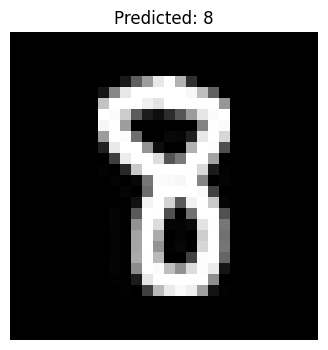

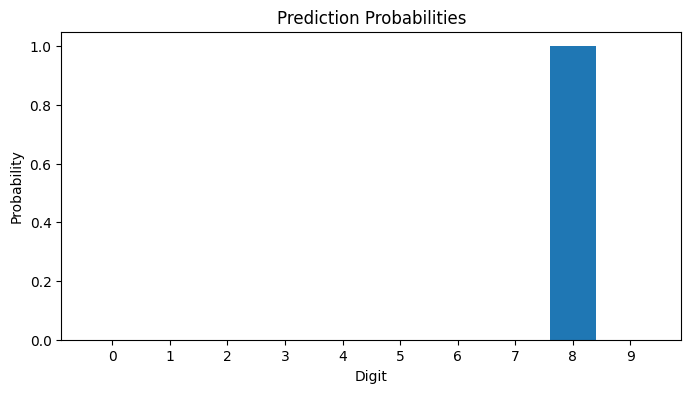

In [69]:
from google.colab.output import eval_js
from base64 import b64decode
from PIL import Image
import io
import numpy as np
import matplotlib.pyplot as plt

# =========================
# DRAW DIGIT CANVAS
# =========================

data_url = eval_js("""
new Promise((resolve) => {
    const oldBox = document.getElementById("digit-canvas-box");
    if (oldBox) oldBox.remove();

    const box = document.createElement("div");
    box.id = "digit-canvas-box";
    box.innerHTML = `
        <div style="font-family:Arial; margin:10px 0;">
            <h3>Draw one digit below, then click Predict</h3>
            <canvas id="digitCanvas" width="280" height="280"
                style="border:2px solid white; background:black; cursor:crosshair; touch-action:none;">
            </canvas>
            <br><br>
            <button id="clearBtn" style="padding:8px 14px; margin-right:8px;">Clear</button>
            <button id="predictBtn" style="padding:8px 14px;">Predict</button>
        </div>
    `;

    document.body.appendChild(box);

    const canvas = document.getElementById("digitCanvas");
    const ctx = canvas.getContext("2d");

    ctx.fillStyle = "black";
    ctx.fillRect(0, 0, canvas.width, canvas.height);

    ctx.strokeStyle = "white";
    ctx.lineWidth = 24;
    ctx.lineCap = "round";
    ctx.lineJoin = "round";

    let drawing = false;

    function getPos(e) {
        const rect = canvas.getBoundingClientRect();

        let clientX, clientY;

        if (e.touches && e.touches.length > 0) {
            clientX = e.touches[0].clientX;
            clientY = e.touches[0].clientY;
        } else {
            clientX = e.clientX;
            clientY = e.clientY;
        }

        return {
            x: clientX - rect.left,
            y: clientY - rect.top
        };
    }

    function startDraw(e) {
        e.preventDefault();
        drawing = true;
        const p = getPos(e);
        ctx.beginPath();
        ctx.moveTo(p.x, p.y);
    }

    function draw(e) {
        if (!drawing) return;
        e.preventDefault();
        const p = getPos(e);
        ctx.lineTo(p.x, p.y);
        ctx.stroke();
    }

    function stopDraw(e) {
        drawing = false;
    }

    canvas.addEventListener("mousedown", startDraw);
    canvas.addEventListener("mousemove", draw);
    canvas.addEventListener("mouseup", stopDraw);
    canvas.addEventListener("mouseleave", stopDraw);

    canvas.addEventListener("touchstart", startDraw, {passive:false});
    canvas.addEventListener("touchmove", draw, {passive:false});
    canvas.addEventListener("touchend", stopDraw);

    document.getElementById("clearBtn").onclick = function() {
        ctx.fillStyle = "black";
        ctx.fillRect(0, 0, canvas.width, canvas.height);
    };

    document.getElementById("predictBtn").onclick = function() {
        resolve(canvas.toDataURL("image/png"));
        box.remove();
    };
})
""")

# =========================
# PREPROCESS CANVAS IMAGE
# =========================

image_data = b64decode(data_url.split(",")[1])
img = Image.open(io.BytesIO(image_data)).convert("L")

arr = np.array(img).astype(np.uint8)

# Ensure black background and white digit
if arr.mean() > 127:
    arr = 255 - arr

# Threshold
arr = np.where(arr > 40, 255, 0).astype(np.uint8)

coords = np.column_stack(np.where(arr > 0))

if coords.size == 0:
    print("No digit detected. Draw again.")
else:
    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0) + 1

    digit_crop = arr[y0:y1, x0:x1]

    crop_img = Image.fromarray(digit_crop)

    w, h = crop_img.size

    # Resize digit to fit inside 20x20 area like MNIST
    scale = 20 / max(w, h)
    new_w = max(1, int(w * scale))
    new_h = max(1, int(h * scale))

    crop_img = crop_img.resize((new_w, new_h), Image.Resampling.LANCZOS)

    final_img = Image.new("L", (28, 28), 0)
    final_img.paste(crop_img, ((28 - new_w) // 2, (28 - new_h) // 2))

    x = np.array(final_img).astype("float32") / 255.0
    x = x.reshape(1, 28, 28, 1)

    prediction = model.predict(x, verbose=0)[0]
    predicted_digit = np.argmax(prediction)
    confidence = np.max(prediction) * 100

    print("Predicted Digit:", predicted_digit)
    print("Confidence:", round(confidence, 2), "%")

    top3 = prediction.argsort()[-3:][::-1]

    print("\nTop 3 Predictions:")
    for i in top3:
        print(f"Digit {i}: {prediction[i] * 100:.2f}%")

    plt.figure(figsize=(4, 4))
    plt.imshow(final_img, cmap="gray")
    plt.title(f"Predicted: {predicted_digit}")
    plt.axis("off")
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.bar(range(10), prediction)
    plt.xticks(range(10))
    plt.xlabel("Digit")
    plt.ylabel("Probability")
    plt.title("Prediction Probabilities")
    plt.show()

Now that we have a global JavaScript function `colabSaveCanvas` defined, we can call it from Python using `eval_js`.

## Softmax Probabilities

In [66]:

for i,p in enumerate(prediction[0]):
    print(f"Digit {i} : {p*100:.2f}%")


Digit 0 : 7.51%
Digit 1 : 9.76%
Digit 2 : 8.17%
Digit 3 : 6.54%
Digit 4 : 14.44%
Digit 5 : 11.40%
Digit 6 : 13.37%
Digit 7 : 7.92%
Digit 8 : 14.77%
Digit 9 : 6.12%
